# Phase 1: Data Collection and Structurally Faithful Preprocessing
This notebook pulls the raw financial datasets (FinQA for fine-tuning, FinanceBench for evaluation) and applies heuristic layout parsing.
It produces structured Markdown tables, generates CoT prompts, and includes EDA for token-length distributions.

## Environment setup
Install or update data processing, visualization, and tokenization libraries.

In [1]:
%pip -q install "datasets>=2.18.0" "pandas>=2.2.0" "numpy>=1.26.0" "matplotlib>=3.8.0" "seaborn>=0.13.0" "tqdm>=4.66.0" "transformers>=4.40.0"

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
IN_VAST = Path("/workspace").exists()

candidate_roots = []
env_root = os.environ.get("FINGEO_PROJECT_ROOT")
if env_root:
    candidate_roots.append(Path(env_root))
if IN_COLAB:
    candidate_roots.extend([
        Path("/content/drive/MyDrive/FinGEO-SLM"),
        Path("/content/FinGEO-SLM"),
    ])
if IN_VAST:
    candidate_roots.extend([Path("/workspace/FinGEO-SLM"), Path("/workspace")])
candidate_roots.append(Path.cwd())

PROJECT_ROOT = next(
    (p for p in candidate_roots if p.exists() and (p / "README.md").exists()),
    Path.cwd(),
)

if IN_COLAB and os.environ.get("FINGEO_MOUNT_DRIVE", "0") == "1":
    from google.colab import drive

    drive.mount("/content/drive", force_remount=False)
    drive_root = Path("/content/drive/MyDrive/FinGEO-SLM")
    if drive_root.exists():
        PROJECT_ROOT = drive_root

os.chdir(PROJECT_ROOT)
print(f"Runtime platform: {'colab' if IN_COLAB else ('vast' if IN_VAST else 'local')}")
print(f"Project root: {PROJECT_ROOT}")

def project_path(*parts):
    return str(PROJECT_ROOT.joinpath(*parts))

## Imports and helper functions
Utilities for parsing tables and formatting CoT prompts.

In [2]:
import os
import json
import textwrap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset, Dataset
from transformers import AutoTokenizer
from tqdm.auto import tqdm

sns.set_theme(style="whitegrid")

def format_table_to_markdown(table_data):
    """Converts raw 2D array financial tables into structurally faithful Markdown."""
    if not table_data or len(table_data) == 0:
        return ""
    try:
        headers = table_data[0]
        rows = table_data[1:]
        df = pd.DataFrame(rows, columns=headers)
        return df.to_markdown(index=False)
    except Exception:
        return str(table_data)

def format_cot_prompt(example):
    """Formats FinQA into a strict CoT prompt for SLM fine-tuning."""
    pre_text = example.get("pre_text", [])
    post_text = example.get("post_text", [])
    table_data = example.get("table", [])
    question = example.get("question", "")
    answer = example.get("answer", "")
    exe_list = example.get("exe_list", [])

    pre_text_str = " ".join(pre_text) if isinstance(pre_text, list) else str(pre_text)
    post_text_str = " ".join(post_text) if isinstance(post_text, list) else str(post_text)
    text_context = pre_text_str + "\n" + post_text_str
    table_context = format_table_to_markdown(table_data)

    if isinstance(exe_list, list) and exe_list and isinstance(exe_list[0], dict):
        reasoning_steps = " -> ".join(
            [
                f"{step.get('op', '')}({step.get('arg1', '')}, {step.get('arg2', '')}) = {step.get('res', '')}"
                for step in exe_list
            ]
        )
    else:
        reasoning_steps = " ".join(exe_list) if isinstance(exe_list, list) else str(exe_list)

    instruction = (
        "You are a highly accurate financial AI. Using the provided context, "
        "answer the question by thinking step-by-step."
    )

    full_prompt = f"""[INST] {instruction}\nContext:\n{text_context}\n\nFinancial Table:\n{table_context}\n\nQuestion: {question}\n[/INST]\nLet's think step by step. \nReasoning: {reasoning_steps}\nFinal Answer: {answer}"""
    return {"formatted_prompt": full_prompt}

/Users/uzmanarfan/.pyenv/versions/3.12.9/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load raw datasets
Read FinQA locally and FinanceBench from the Hugging Face Hub with defensive parsing.

In [ ]:
print("Loading datasets...")
finqa_path = project_path("data", "finQA", "train.json")

try:
    with open(finqa_path, "r", encoding="utf-8") as f:
        raw_finqa_data = json.load(f)
except FileNotFoundError as exc:
    raise FileNotFoundError(f"Missing FinQA file at {finqa_path}") from exc
except json.JSONDecodeError as exc:
    raise ValueError("FinQA JSON is malformed") from exc

cleaned_finqa = []
for item in tqdm(raw_finqa_data, desc="Cleaning FinQA", unit="example"):
    qa_data = item.get("qa", {})
    cleaned_finqa.append(
        {
            "pre_text": item.get("pre_text", []),
            "post_text": item.get("post_text", []),
            "table": item.get("table", []),
            "question": qa_data.get("question", ""),
            "answer": str(qa_data.get("answer", "")),
            "exe_list": qa_data.get("exe_list", qa_data.get("steps", [])),
        }
    )

finqa_dataset = Dataset.from_list(cleaned_finqa)

try:
    financebench_dataset = load_dataset("PatronusAI/financebench", split="train")
except Exception as exc:
    raise RuntimeError("Failed to load FinanceBench from the Hub") from exc

print(
    f"FinQA samples: {len(finqa_dataset)} | FinanceBench samples: {len(financebench_dataset)}"
)

Loading datasets...


Cleaning FinQA: 100%|██████████| 6251/6251 [00:00<00:00, 97299.42example/s]


FinQA samples: 6251 | FinanceBench samples: 150


## Apply CoT formatting and persist
Map into the final prompt format and save to disk with progress bars.

In [ ]:
print("Applying CoT formatting and parsing tables...")
finqa_cot_dataset = finqa_dataset.map(format_cot_prompt, desc="Formatting FinQA prompts")

os.makedirs(project_path("processed_data"), exist_ok=True)
finqa_cot_dataset.save_to_disk(project_path("processed_data", "finqa_cot"))
financebench_dataset.save_to_disk(project_path("processed_data", "financebench"))

print(f"Preprocessing complete. Data saved to: {project_path('processed_data')}")

Applying CoT formatting and parsing tables...


Saving the dataset (1/1 shards): 100%|██████████| 150/150 [00:00<00:00, 34981.68 examples/s]

Preprocessing complete. Data saved to processed_data/


## EDA: token length distribution
Compute token lengths for formatted prompts and inspect a sample CoT prompt.

Computing token lengths: 100%|██████████| 2000/2000 [00:00<00:00, 5786.38 examples/s]


Token length stats -> min: 281 | max: 3671 | mean: 1228.84


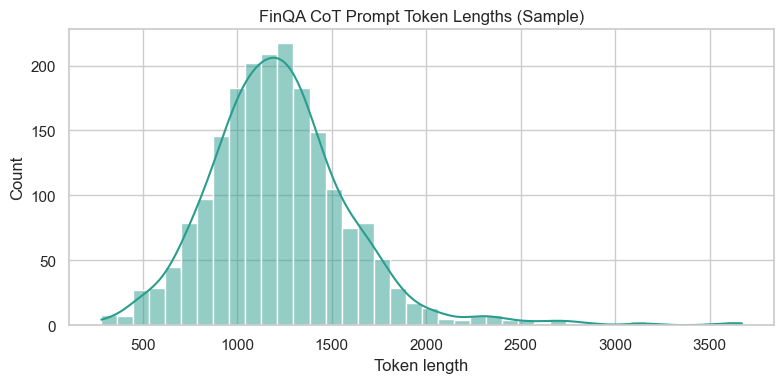

Sample formatted_prompt:

[INST] You are a highly accurate financial AI. Using the provided context, answer the question by
thinking step-by-step. Context: interest rate to a variable interest rate based on the three-month
libor plus 2.05% ( 2.05 % ) ( 2.34% ( 2.34 % ) as of october 31 , 2009 ) . if libor changes by 100
basis points , our annual interest expense would change by $ 3.8 million . foreign currency exposure
as more fully described in note 2i . in the notes to consolidated financial statements contained in
item 8 of this annual report on form 10-k , we regularly hedge our non-u.s . dollar-based exposures
by entering into forward foreign currency exchange contracts . the terms of these contracts are for
periods matching the duration of the underlying exposure and generally range from one month to
twelve months . currently , our largest foreign currency exposure is the euro , primarily because
our european operations have the highest proportion of our local currency denominate

In [5]:
try:
    tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")
    sample_size = min(2000, len(finqa_cot_dataset))
    eda_sample = finqa_cot_dataset.select(range(sample_size))

    def add_token_length(batch):
        tokenized = tokenizer(batch["formatted_prompt"], add_special_tokens=False)
        return {"token_length": [len(ids) for ids in tokenized["input_ids"]]}

    eda_with_len = eda_sample.map(add_token_length, batched=True, desc="Computing token lengths")
    lengths = eda_with_len["token_length"]

    print(
        f"Token length stats -> min: {min(lengths)} | max: {max(lengths)} | mean: {np.mean(lengths):.2f}"
)
    plt.figure(figsize=(8, 4))
    sns.histplot(lengths, bins=40, kde=True, color="#2a9d8f")
    plt.title("FinQA CoT Prompt Token Lengths (Sample)")
    plt.xlabel("Token length")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    sample_prompt = finqa_cot_dataset[0]["formatted_prompt"]
    print("Sample formatted_prompt:\n")
    print(textwrap.fill(sample_prompt, width=100))
except Exception as exc:
    print(f"EDA failed: {exc}")

## Output validation
Run strict checks to confirm preprocessing artifacts and schema were produced correctly.

In [ ]:
assert len(finqa_dataset) > 0, "FinQA dataset is empty"
assert len(financebench_dataset) > 0, "FinanceBench dataset is empty"
assert len(finqa_cot_dataset) > 0, "Formatted FinQA dataset is empty"
assert "formatted_prompt" in finqa_cot_dataset.column_names, "formatted_prompt column missing"
assert os.path.exists(project_path("processed_data", "finqa_cot")), "processed_data/finqa_cot not found"
assert os.path.exists(project_path("processed_data", "financebench")), "processed_data/financebench not found"
print("Validation complete: Phase 1 notebook executed end-to-end successfully.")


Validation complete: Phase 1 notebook executed end-to-end successfully.
